# Parameter estimation results

This notebook inspects the results from the various parameter estimation runs.


---

In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import corner
import sys


def diagnostics(fname):
    inf_data = az.from_netcdf(fname)
    print(f"Successfully loaded InferenceData from: {fname}")


    # --- 1. Get Full Summary ---
    print("\n--- Calculating Full MCMC Summary ---")
    # Calculate summary for ALL variables first
    full_summary_df = az.summary(inf_data, kind='all', round_to=3, hdi_prob=0.94) # Using default HDI

    # print(full_summary_df['sd'])



    # --- 2. Filter out Constant Deterministic Variables ---
    # Identify variables with near-zero standard deviation (likely constants)
    # Use a small tolerance instead of exact zero for floating point comparisons
    tolerance = 1e-12
    is_sampled_or_derived = full_summary_df['sd'] > tolerance
    sampled_summary_df = full_summary_df[is_sampled_or_derived]

    print("\n--- Filtered MCMC Summary (Excluding Constant Deterministics) ---")
    if sampled_summary_df.empty:
        print("Warning: No variables with standard deviation > tolerance found. Check model or tolerance.")
    else:
        print(sampled_summary_df)

    # --- 3. Diagnostics on Filtered Parameters ---
    if not sampled_summary_df.empty:
        print("\n--- Interpretation Guidance (Filtered Parameters) ---")
        print("Checking R-hat and ESS only for variables that showed variation:")
        # Check R-hat
        max_rhat = sampled_summary_df['r_hat'].max()
        print(f"\nMaximum R-hat value (filtered): {max_rhat:.3f}")
        if max_rhat > 1.05:
            print("WARNING: Maximum R-hat is high (> 1.05), suggesting potential convergence issues. Consider increasing 'num_warmup'.")
        elif max_rhat > 1.01:
            print("NOTE: Maximum R-hat is slightly elevated (> 1.01). Check trace plots carefully.")
        else:
            print("R-hat values look good (<= 1.01).")

        # Check ESS
        min_ess_bulk = sampled_summary_df['ess_bulk'].min()
        min_ess_tail = sampled_summary_df['ess_tail'].min()
        print(f"Minimum Bulk ESS (filtered): {min_ess_bulk:.0f}")
        print(f"Minimum Tail ESS (filtered): {min_ess_tail:.0f}")
        if min_ess_bulk < 400 or min_ess_tail < 400:
            print("WARNING: Minimum ESS is low (< 400). Consider increasing 'num_samples'.")
        else:
            print("ESS values look sufficient (>= 400).")

        # --- 4. Trace Plots for Filtered Parameters ---
        print("\n--- Generating Trace Plots (Filtered Parameters) ---")
        # Get the names of the variables to plot from the filtered summary index
        var_names_to_plot = sampled_summary_df.index.tolist()

        if var_names_to_plot:
            try:
                trace_plot = az.plot_trace(inf_data, var_names=var_names_to_plot, compact=True)
                plt.tight_layout()
                print("Displaying trace plots...")
                plt.show()
            except Exception as e:
                print(f"Could not generate trace plots: {e}")
        else:
            print("No variables left to plot after filtering.")

        print("\n--- Trace Plot Interpretation ---")
        print("(Interpret as before, focusing on these non-constant variables)")

    else:
        print("\nSkipping detailed diagnostics as no non-constant parameters were found in the summary.")


    # --- 5. Divergent Transitions (Applies to the whole sampler run) ---
    # This check remains the same as it reflects the sampler's overall behavior
    print("\n--- Checking for Divergent Transitions ---")
    if "sample_stats" in inf_data and "diverging" in inf_data.sample_stats:
        # ... (rest of divergence check code is identical to previous version) ...
        divergences = inf_data.sample_stats["diverging"].sum().item() # .item() gets scalar value
        total_samples = inf_data.posterior.dims["chain"] * inf_data.posterior.dims["draw"]
        print(f"Total number of divergent transitions: {divergences}")
        print(f"Total post-warmup samples: {total_samples}")
        if divergences > 0:
            divergence_rate = (divergences / total_samples) * 100
            print(f"Divergence rate: {divergence_rate:.2f}%")
            print("WARNING: Divergences indicate potential issues exploring the posterior.")
            print("Consider:")
            print("  1. Model Reparameterization (e.g., non-centered parameterization).")
            print("  2. Increasing 'target_accept_prob' in the NUTS kernel (e.g., kernel = NUTS(model, target_accept_prob=0.90 or 0.95)).")
            print("  3. Using stronger priors if appropriate.")
        else:
            print("No divergent transitions found. Good!")
    else:
        print("Divergence information not found in sample_stats.")


    print("\n--- Diagnostics Complete ---")

def posterior_plot(data_file,parameters,log_scale,ranges):
    # Load data
    data = az.from_netcdf(data_file)
    
    # Validate input lists have same length
    if not (len(parameters) == len(ranges) == len(log_scale)):
        raise ValueError("parameters, ranges and log_scale lists must have same length")
        
    # Get samples for each parameter
    samples = []
    for param in parameters:
        if param not in data.posterior:
            raise ValueError(f"Parameter {param} not found in data")
        samples.append(data.posterior[param].values.flatten())
    
    samples = np.column_stack(samples)
    
    # Apply log transform where specified and adjust ranges accordingly
    for i, (param, do_log) in enumerate(zip(parameters, log_scale)):
        if do_log:
            samples[:,i] = np.log10(samples[:,i])
            parameters[i] = f"log({param})"
            ranges[i] = (np.log10(ranges[i][0]), np.log10(ranges[i][1]))


    print("the ranges are:", ranges)

    # Create corner plot
    fig = corner.corner(
        samples,
        labels=['log(ha)'],
        quantiles=[0.16, 0.5, 0.84],
        show_titles=True,
        title_kwargs={"fontsize": 12},
        range=ranges,
        bins=30,  # Adjust number of bins as needed
        smooth=1.0,  # Adjust smoothing as needed
        plot_datapoints=True,
        fill_contours=True,
        levels=[0.68, 0.95]  # 1 and 2 sigma contours
    )

    plt.tight_layout()
    plt.show()





# 1. MDC2, dataset iib. Just $h_a$

../examples/outputs/mdc2_parameter_estimation_NUTS_results_2025-05-06_11-57-39.nc
Successfully loaded InferenceData from: ../examples/outputs/mdc2_parameter_estimation_NUTS_results_2025-05-06_11-57-39.nc

--- Calculating Full MCMC Summary ---


/fred/oz022/tkimpson/conda_envs/Argus/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/fred/oz022/tkimpson/conda_envs/Argus/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)



--- Filtered MCMC Summary (Excluding Constant Deterministics) ---
            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
log10_ha -15.517  0.071 -15.652  -15.388      0.002    0.001  1462.057   

          ess_tail  r_hat  
log10_ha  1217.062  1.002  

--- Interpretation Guidance (Filtered Parameters) ---
Checking R-hat and ESS only for variables that showed variation:

Maximum R-hat value (filtered): 1.002
R-hat values look good (<= 1.01).
Minimum Bulk ESS (filtered): 1462
Minimum Tail ESS (filtered): 1217
ESS values look sufficient (>= 400).

--- Generating Trace Plots (Filtered Parameters) ---
Displaying trace plots...


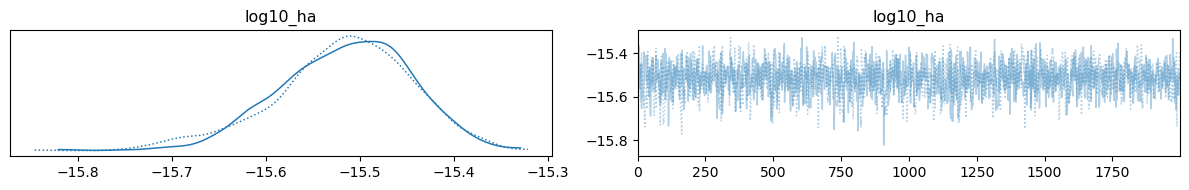


--- Trace Plot Interpretation ---
(Interpret as before, focusing on these non-constant variables)

--- Checking for Divergent Transitions ---
Total number of divergent transitions: 0
Total post-warmup samples: 4000
No divergent transitions found. Good!

--- Diagnostics Complete ---
the ranges are: [(-17.0, -14.0)]


/tmp/ipykernel_1395900/2406551971.py:88: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  total_samples = inf_data.posterior.dims["chain"] * inf_data.posterior.dims["draw"]


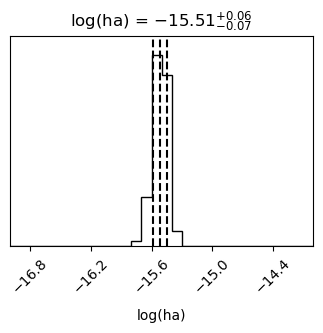

In [2]:
#fname = '../sandbox/outputs/mdc3_parameter_estimation_results_2025-04-25_13-12-25.nc'
#fname = '../sandbox/outputs/mdc3_parameter_estimation_results_2025-04-25_15-17-53.nc'
#fname = '../sandbox/outputs/mdc3_parameter_estimation_results_2025-04-25_15-55-58.nc'
#fname = '../sandbox/outputs/mdc2_parameter_estimation_NUTS_results_2025-04-25_17-04-24.nc'


#fname1 = '../examples/outputs/mdc2_parameter_estimation_NUTS_results_2025-04-26_16-49-52.nc'
#fname2 = '../sandbox/outputs/mdc2_parameter_estimation_NUTS_results_2025-04-27_22-46-20.nc'
#fname3= '../examples/outputs/mdc2_parameter_estimation_NUTS_results_2025-05-02_14-35-34.nc'

fname4 = '../examples/outputs/mdc2_parameter_estimation_NUTS_results_2025-05-06_11-57-39.nc'

# print(fname1)
# diagnostics(fname1)
# posterior_plot(fname1,parameters=['ha'],log_scale=[True],ranges=[(1e-16, 1e-14)])



# print(fname2)
# diagnostics(fname2)
# posterior_plot(fname2,parameters=['ha'],log_scale=[True],ranges=[(1e-17, 1e-14)])




print(fname4)
diagnostics(fname4)
posterior_plot(fname4,parameters=['ha'],log_scale=[True],ranges=[(1e-17, 1e-14)])




# 2. MDC2 dataset, 3 params, NUTS

../examples/outputs/mdc2_parameter_estimation_NUTS_results_2025-05-08_06-17-36.nc
Successfully loaded InferenceData from: ../examples/outputs/mdc2_parameter_estimation_NUTS_results_2025-05-08_06-17-36.nc

--- Calculating Full MCMC Summary ---


/fred/oz022/tkimpson/conda_envs/Argus/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/fred/oz022/tkimpson/conda_envs/Argus/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)



--- Filtered MCMC Summary (Excluding Constant Deterministics) ---
                mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
log10_ha     -16.517  0.307 -16.997  -16.000      0.005    0.004  3093.423   
log10_γp[0]   -6.903  0.667  -8.112   -6.000      0.010    0.007  3467.161   
log10_γp[1]   -8.347  1.376 -10.448   -6.000      0.026    0.019  2476.371   
log10_γp[2]   -7.286  0.965  -9.074   -6.000      0.013    0.009  4320.077   
log10_γp[3]   -6.881  0.508  -7.699   -6.026      0.008    0.006  3794.171   
...              ...    ...     ...      ...        ...      ...       ...   
log10_σp[27] -17.559  0.348 -17.999  -16.912      0.005    0.004  3042.817   
log10_σp[28] -17.568  0.337 -18.000  -16.934      0.005    0.004  3443.145   
log10_σp[29] -17.512  0.351 -17.999  -16.883      0.006    0.005  2774.116   
log10_σp[30] -17.283  0.535 -17.999  -16.315      0.009    0.006  3094.814   
log10_σp[31] -17.591  0.322 -18.000  -16.990      0.005    0.004  3239.576 

/tmp/ipykernel_2384935/2406551971.py:88: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  total_samples = inf_data.posterior.dims["chain"] * inf_data.posterior.dims["draw"]


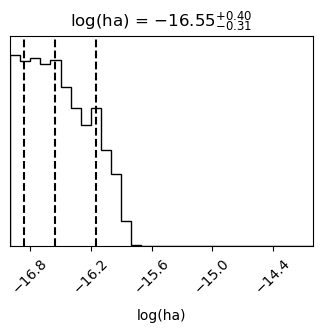

In [2]:
fname = '../examples/outputs/mdc2_parameter_estimation_NUTS_results_2025-05-08_06-17-36.nc'
print(fname)
diagnostics(fname)
posterior_plot(fname,parameters=['ha'],log_scale=[True],ranges=[(1e-17, 1e-14)])



# JAXNS nested sampling 

In [1]:
from jaxns import load_results 
import numpy as np 
import corner
import matplotlib.pyplot as plt

def plot_jaxns_corner(results,parameters,ranges):

    # Get samples for each selected parameter
    samples = []
    for param in parameters:
        if param not in results.samples :
            raise ValueError(f"Parameter {param} not found in data")
        samples.append(results.samples[param].flatten())

    samples = np.column_stack(samples)


    evidence = results.log_Z_mean.item()
    evidence_std = results.log_Z_uncert.item()

    print("The log evidence is:", evidence, "with a standard deviation of:", evidence_std)



    # Create corner plot
    # https://corner.readthedocs.io/en/latest/api/#corner.corner
    fig = corner.corner(
        samples,
        labels=parameters,
        color='C0',
        quantiles=[0.16, 0.5, 0.84],
        show_titles=True,
        title_kwargs={"fontsize": 12},
        range=ranges,
        bins=30,  # Adjust number of bins as needed
        smooth=1.0,  # Adjust smoothing as needed
        smooth1d=1.0,
        plot_datapoints=True,
        fill_contours=True,
        levels=[0.68, 0.95]  # 1 and 2 sigma contours
    )

    plt.tight_layout()
    plt.show()



def plot_jaxns_corner_vector(results,param,ranges,dim):

    # Get samples for each selected parameter
    samples = []
    for i in range(dim):
        samples_i = results.samples[param][:,i].flatten()
        samples.append(samples_i)

    samples = np.column_stack(samples)


    evidence = results.log_Z_mean.item()
    evidence_std = results.log_Z_uncert.item()

    print("The log evidence is:", evidence, "with a standard deviation of:", evidence_std)


    labels = [f"{param}_{i}" for i in range(dim)]

    # Create corner plot
    # https://corner.readthedocs.io/en/latest/api/#corner.corner
    fig = corner.corner(
        samples,
        labels=labels,
        color='C0',
        quantiles=[0.16, 0.5, 0.84],
        show_titles=True,
        title_kwargs={"fontsize": 12},
        range=ranges,
        bins=30,  # Adjust number of bins as needed
        smooth=1.0,  # Adjust smoothing as needed
        smooth1d=1.0,
        plot_datapoints=True,
        fill_contours=True,
        levels=[0.68, 0.95]  # 1 and 2 sigma contours
    )

    plt.tight_layout()
    plt.show()









/fred/oz022/tkimpson/conda_envs/Argus/lib/python3.12/site-packages/jaxns/internals/mixed_precision.py:14: UserWarning: JAX x64 is not enabled. Setting it now. Check for errors.
  warnings.warn("JAX x64 is not enabled. Setting it now. Check for errors.")
INFO:2025-05-16 12:46:59,966:jax._src.xla_bridge:925: Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
INFO:jax._src.xla_bridge:Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
INFO:2025-05-16 12:46:59,971:jax._src.xla_bridge:925: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


## Just ha 

The log evidence is: 56032.26359244883 with a standard deviation of: 0.4747503293252449


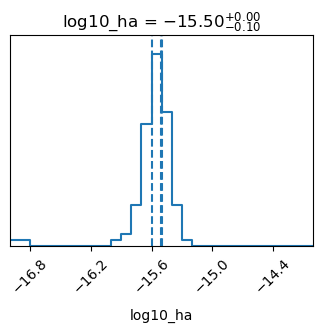

In [6]:
d = '../examples/outputs/example_nested_sampling_results_2025-05-06_14-36-21'
results = load_results(d)
parameters=['log10_ha']
ranges=[(-17, -14)]
plot_jaxns_corner(results,parameters,ranges)





The log evidence is: 56032.26359244883 with a standard deviation of: 0.4747503293252449


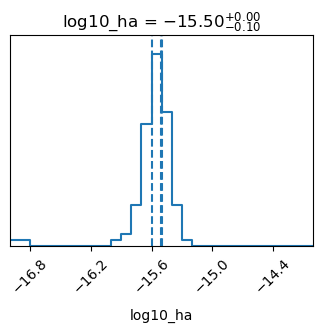

In [7]:
d = '../examples/outputs/example_nested_sampling_results_2025-05-15_09-18-04'
results = load_results(d)
parameters=['log10_ha']
ranges=[(-17, -14)]
plot_jaxns_corner(results,parameters,ranges)


The log evidence is: 56032.260517410476 with a standard deviation of: 0.4751325353566443


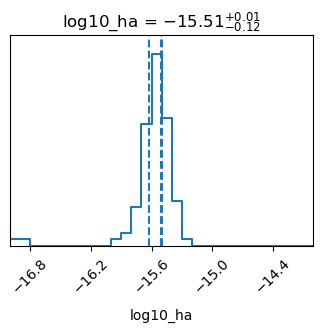

In [8]:
d = '../examples/outputs/example_nested_sampling_results_2025-05-15_17-04-41'
results = load_results(d)
parameters=['log10_ha']
ranges=[(-17, -14)]
plot_jaxns_corner(results,parameters,ranges)




The log evidence is: 56032.26359244883 with a standard deviation of: 0.4747503293252449


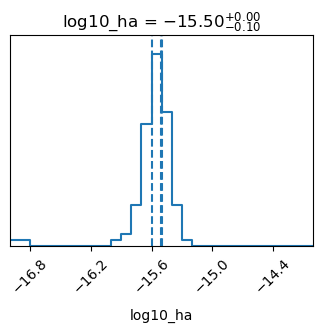

In [2]:





d = '../examples/outputs/example_nested_sampling_results_2025-05-16_12-25-28'
results = load_results(d)
parameters=['log10_ha']
ranges=[(-17, -14)]
plot_jaxns_corner(results,parameters,ranges)





## multi params 

In [4]:
d = '../examples/outputs/example_nested_sampling_results_2025-05-07_22-14-50'
results = load_results(d)

The log evidence is: 56032.3767411451 with a standard deviation of: 0.17592067545200016


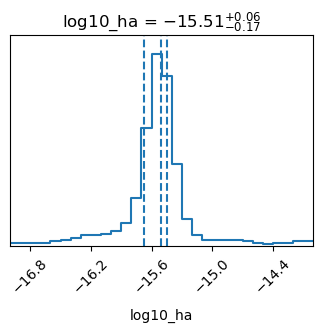

In [5]:
parameters=['log10_ha']
ranges=[(-17, -14)]
plot_jaxns_corner(results,parameters,ranges)

The log evidence is: 56032.3767411451 with a standard deviation of: 0.17592067545200016


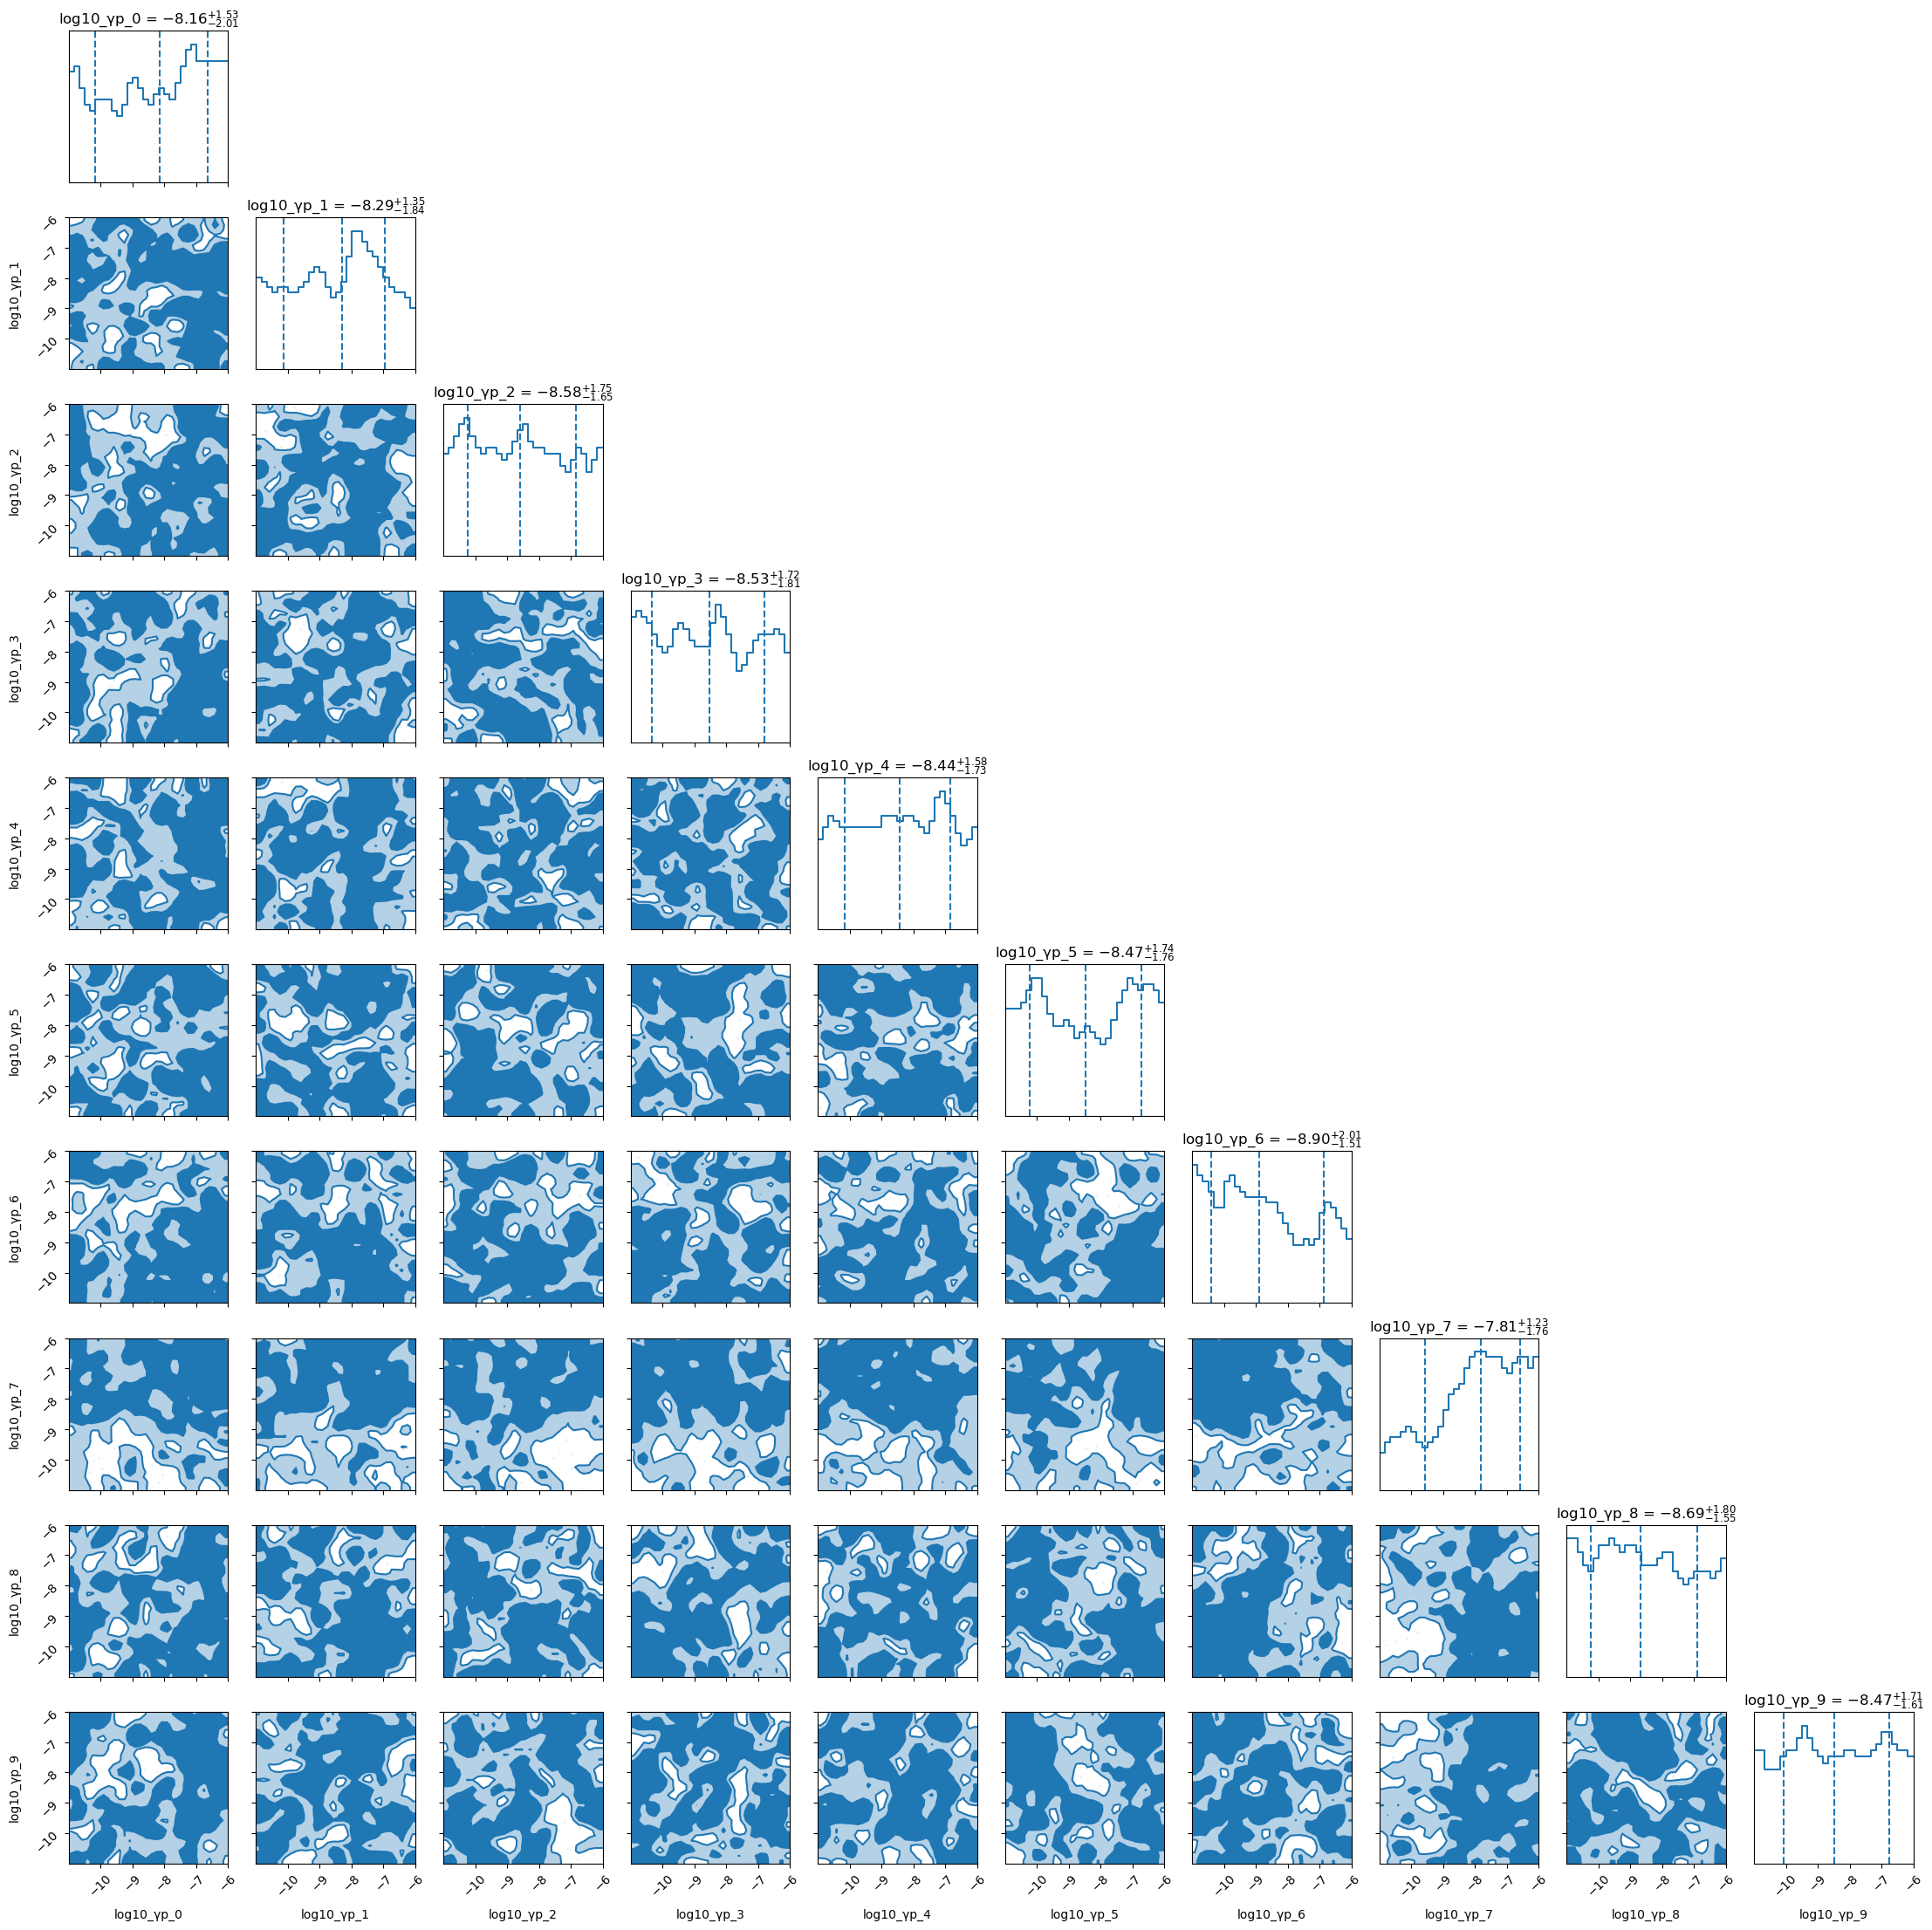

In [16]:
dim = 10
plot_jaxns_corner_vector(results,param='log10_γp',ranges=[(-11, -6) for i in range(dim)],dim=dim)

The log evidence is: 56032.3767411451 with a standard deviation of: 0.17592067545200016


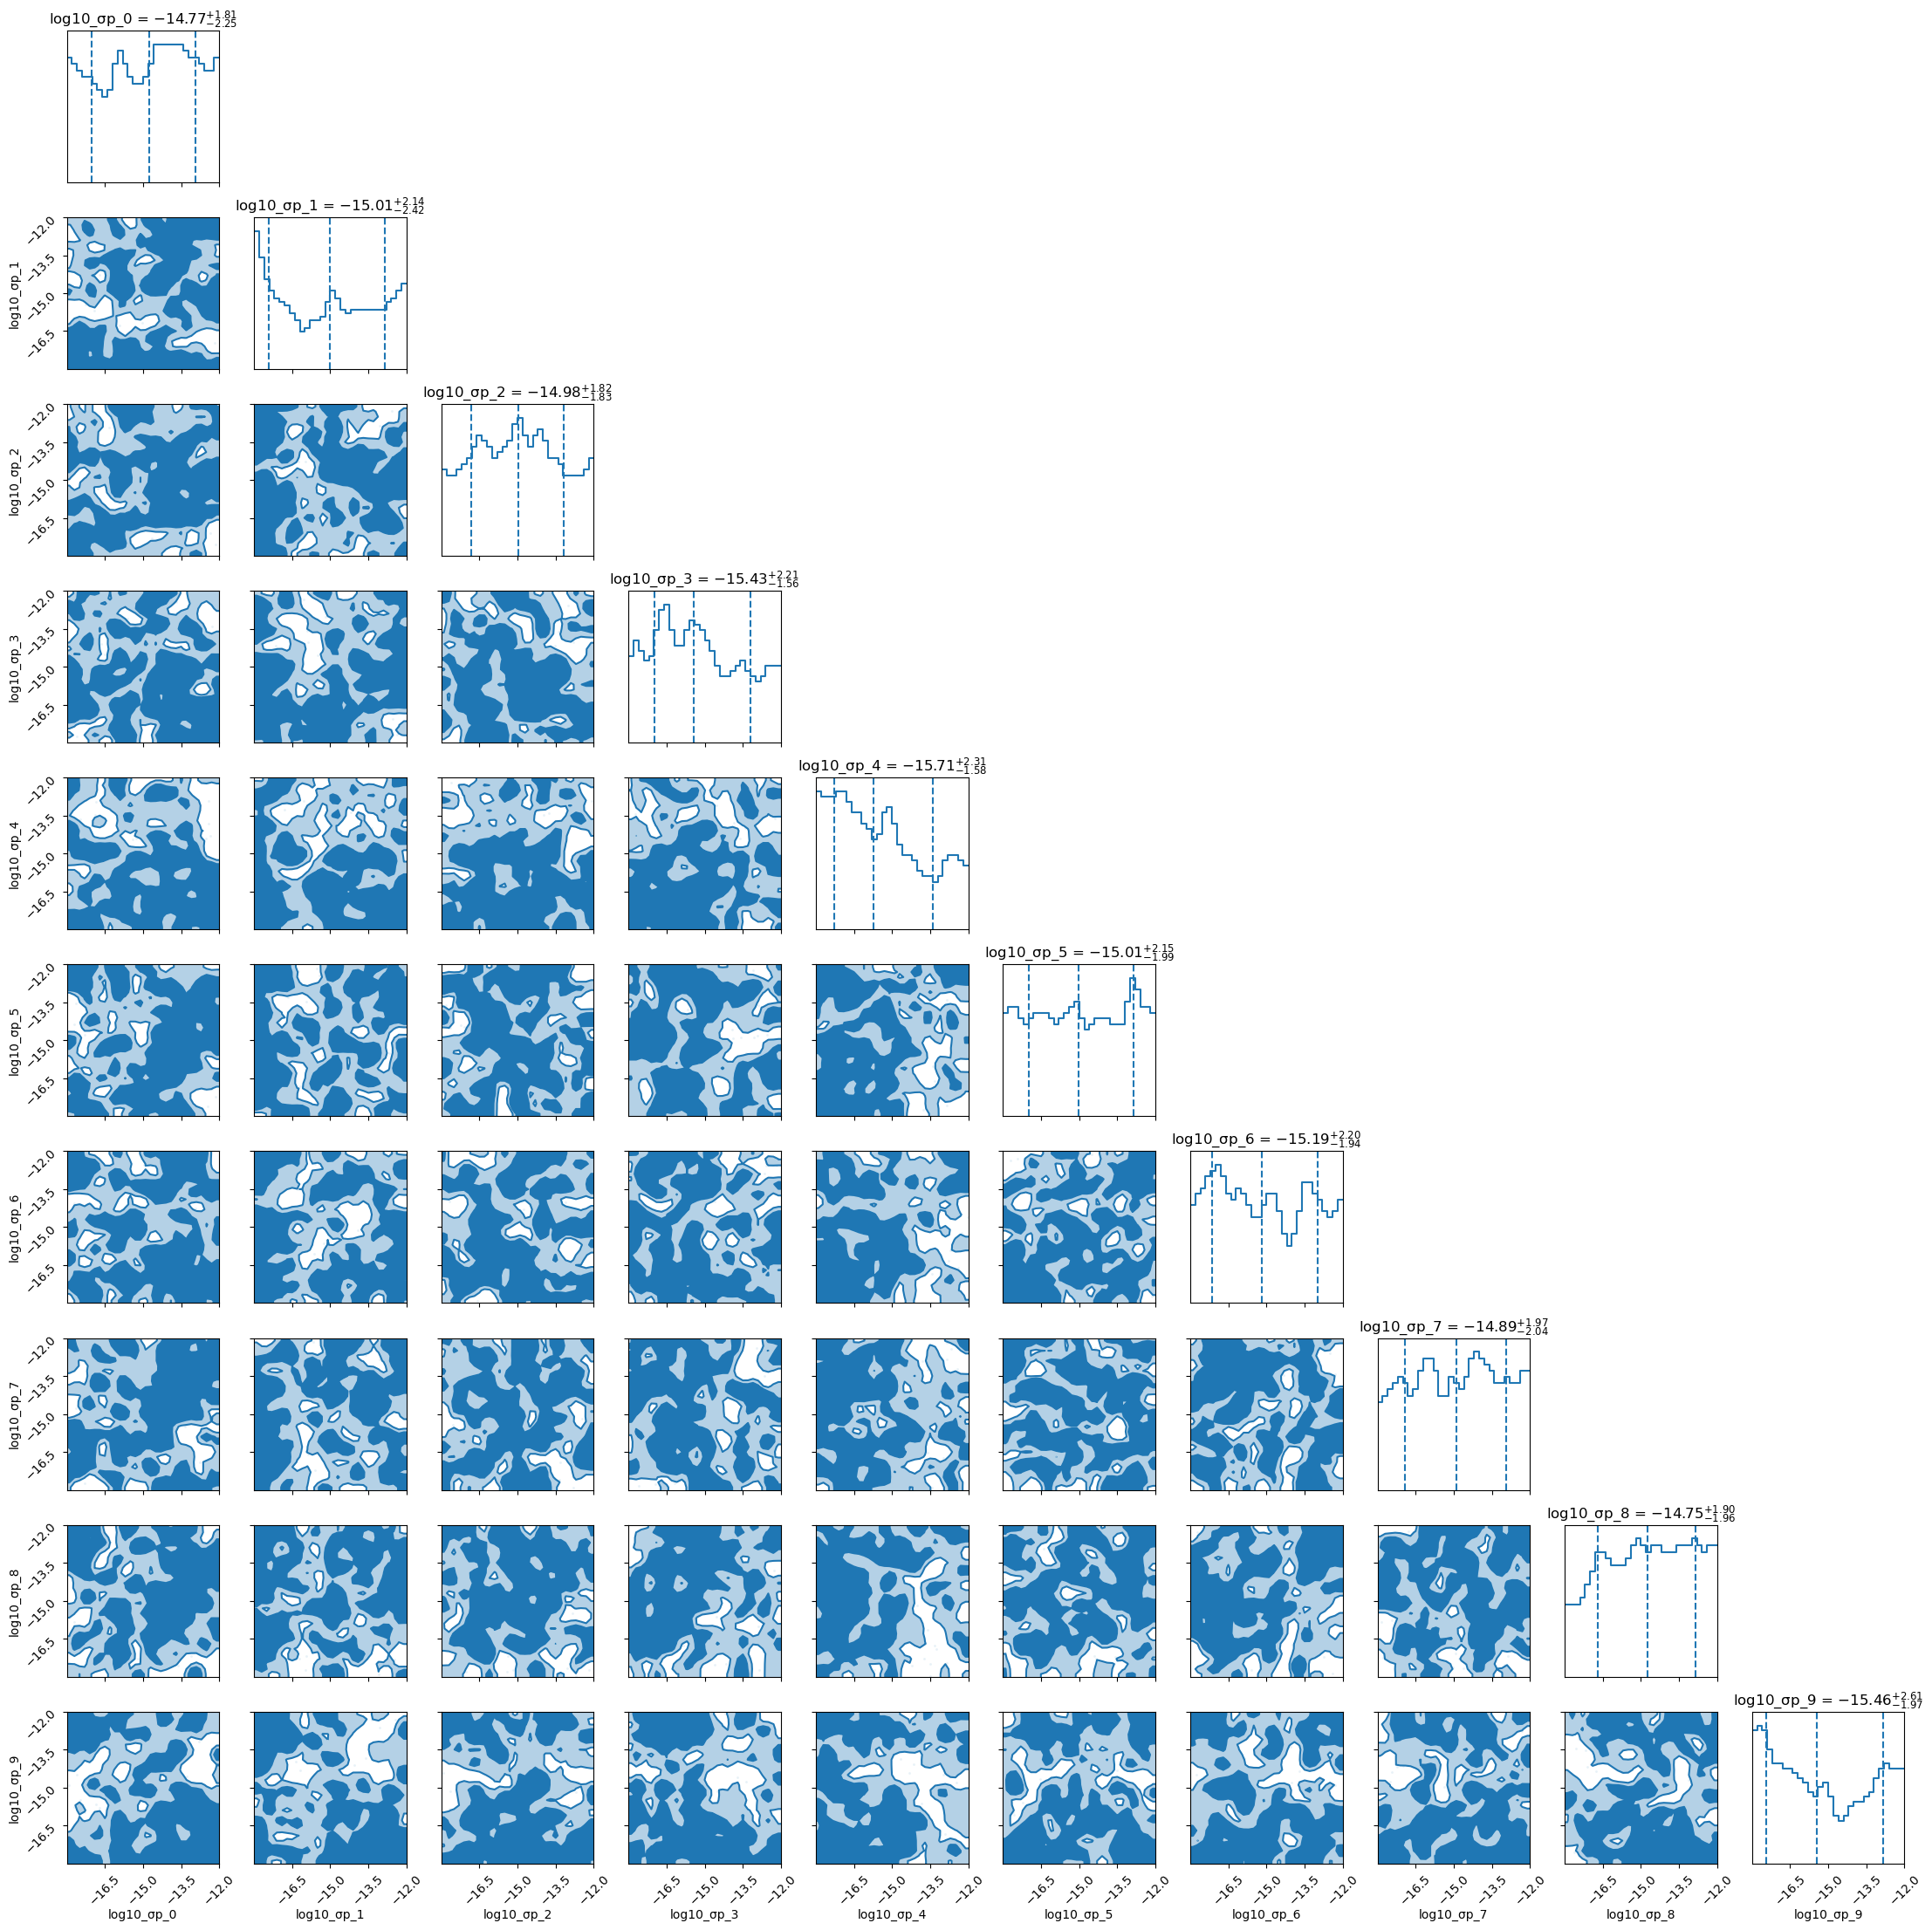

In [15]:
dim=10 
plot_jaxns_corner_vector(results,param='log10_σp',ranges=[(-18, -12) for i in range(dim)],dim=dim)

In [8]:
results.samples['log10_γp'].shape


(550, 32)

In [ ]:
    samples = []
    for param in parameters:
        if param not in results.samples :
            raise ValueError(f"Parameter {param} not found in data")
        samples.append(results.samples[param].flatten())

    samples = np.column_stack(samples)


# Null model 

In [1]:
d = d = '../examples/outputs/example_nested_sampling_results_2025-05-08_12-44-38'
results = load_results(d)

NameError: name 'load_results' is not defined